In [147]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import numpy as np 
import matplotlib.pyplot as plt 
import torch.optim as optim
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import time
import requests
from torchsummary import summary

In [72]:
file_location='./input.txt'

with open(file_location) as f:
    text=f.read().strip()
chars= sorted(list(set(text)))
char_to_idx= dict()
idx_to_char = dict()
for index,val in enumerate(chars):
    char_to_idx[val]=index
    idx_to_char[index]=val

#encode text
vocab_size=len(char_to_idx)
encoded_text= [char_to_idx[ch]for ch in text]
print(f" text length: {len(text)} characters")
print(f"vocab_size: {vocab_size}")
print(f"First 20 encoded: {encoded_text[:20]}")
print(f"Which decodes to: {''.join([idx_to_char[i] for i in encoded_text[:20]])}")



 text length: 2386 characters
vocab_size: 45
First 20 encoded: [13, 23, 42, 38, 1, 21, 26, 19, 36, 19, 21, 38, 23, 36, 1, 34, 36, 23, 22, 27]
Which decodes to: Next character predi


In [143]:
#shakespeare text 
# Step 1: Download the dataset
def load_shakespeare():
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    response = requests.get(url)
    text = response.text  # This is the entire text data
    chars=sorted(list(set(text)))
    char_to_idx= dict()
    idx_to_char = dict()
    for index,val in enumerate(chars):
        char_to_idx[val]=index
        idx_to_char[index]=val

    vocab_size=len(char_to_idx)
    encoded_text= [char_to_idx[ch]for ch in text]
    #print(f" text length: {len(text)} characters")
    #print(f"vocab_size: {vocab_size}")
    #print(f"First 20 encoded: {encoded_text[:20]}")
    #print(f"Which decodes to: {''.join([idx_to_char[i] for i in encoded_text[:20]])}")
    return encoded_text
shakespeare_encoded_text=load_shakespeare()
shakespeare_encoded_text # vocab size = 67

[18,
 47,
 56,
 57,
 58,
 1,
 15,
 47,
 58,
 47,
 64,
 43,
 52,
 10,
 0,
 14,
 43,
 44,
 53,
 56,
 43,
 1,
 61,
 43,
 1,
 54,
 56,
 53,
 41,
 43,
 43,
 42,
 1,
 39,
 52,
 63,
 1,
 44,
 59,
 56,
 58,
 46,
 43,
 56,
 6,
 1,
 46,
 43,
 39,
 56,
 1,
 51,
 43,
 1,
 57,
 54,
 43,
 39,
 49,
 8,
 0,
 0,
 13,
 50,
 50,
 10,
 0,
 31,
 54,
 43,
 39,
 49,
 6,
 1,
 57,
 54,
 43,
 39,
 49,
 8,
 0,
 0,
 18,
 47,
 56,
 57,
 58,
 1,
 15,
 47,
 58,
 47,
 64,
 43,
 52,
 10,
 0,
 37,
 53,
 59,
 1,
 39,
 56,
 43,
 1,
 39,
 50,
 50,
 1,
 56,
 43,
 57,
 53,
 50,
 60,
 43,
 42,
 1,
 56,
 39,
 58,
 46,
 43,
 56,
 1,
 58,
 53,
 1,
 42,
 47,
 43,
 1,
 58,
 46,
 39,
 52,
 1,
 58,
 53,
 1,
 44,
 39,
 51,
 47,
 57,
 46,
 12,
 0,
 0,
 13,
 50,
 50,
 10,
 0,
 30,
 43,
 57,
 53,
 50,
 60,
 43,
 42,
 8,
 1,
 56,
 43,
 57,
 53,
 50,
 60,
 43,
 42,
 8,
 0,
 0,
 18,
 47,
 56,
 57,
 58,
 1,
 15,
 47,
 58,
 47,
 64,
 43,
 52,
 10,
 0,
 18,
 47,
 56,
 57,
 58,
 6,
 1,
 63,
 53,
 59,
 1,
 49,
 52,
 53,
 61,
 1,
 15,
 39,
 47,

In [73]:
def create_input_output_seq(encoded_text,seq_len):
    inputs=[]
    targets=[]
    for i in range(len(encoded_text)-seq_len):
        input_seq=encoded_text[i:i+seq_len]
        target_seq=encoded_text[i+1:i+seq_len+1]
        inputs.append(input_seq)
        targets.append(target_seq)
    X=np.array(inputs)
    y=np.array(targets)

    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
    X_train=torch.tensor(X_train,dtype=torch.long)
    X_test=torch.tensor(X_test,dtype=torch.long)
    y_train=torch.tensor(y_train,dtype=torch.long)
    y_test=torch.tensor(y_test,dtype=torch.long)

    print(f"\nseq_len = {seq_len}")
    print(f"  Total samples : {len(X)}")
    print(f"  X_train shape : {X_train.shape}")   # (N_train, seq_len)
    print(f"  y_train shape : {y_train.shape}")   # (N_train, seq_len)
    print(f"  X_test shape   : {X_test.shape}")
    print(f"  y_test shape   : {y_test.shape}")

    return X_train, X_test, y_train, y_test

    


In [95]:
class CharRNN(nn.Module):
    def __init__(self, eta, n_iter,batch_size, random_state, embed_size, vocab_size, hidden_size):
        super().__init__()
        self.eta=eta
        self.n_iter = n_iter
        self.batch_size=batch_size
        self.random_state= random_state
        self.hidden_size = hidden_size 

        torch.manual_seed(self.random_state)
        self.device = torch.device("cuda" if torch.cuda.is_available()else "mps" if torch.backends.mps.is_available else "cpu")
        print(f'Using {self.device}')

        self.embedding=nn.Embedding(vocab_size,embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)  # RNN layer H_t
        self.fc = nn.Linear(hidden_size, vocab_size)  # Linear layer for output

        self.train_losses_     = []
        self.train_accuracies_ = []
        self.val_losses_       = []
        self.val_accuracies_   = []
        self.to(self.device)

    def forward(self,x):
        x=self.embedding(x)
        output,h_n=self.rnn(x)
        logits=self.fc(output) #get output of the last RNN cell 
        return logits 
    
    def fit(self,X_train,y_train,X_test,y_test):
        start_time=time.time()
        optimizer = optim.Adam(self.parameters(),lr=self.eta, weight_decay=0.001)
        criterion= nn.CrossEntropyLoss()
        train_loader=self.iter_mini_batch(X_train,y_train)
        for epoch in range(self.n_iter):
            epoch_start=time.time()
            self.train()
            running_loss=0.0
            correct=0
            total =0
            for xin,target in train_loader:
                xin=xin.to(self.device)
                target=target.to(self.device)
                optimizer.zero_grad()
                y_hat=self(xin)
                loss = criterion(y_hat.view(-1, y_hat.size(-1)), target.view(-1))
                loss.backward()
                optimizer.step()

                running_loss+=loss.item()
                preds = y_hat.argmax(dim=-1)
                correct += (preds == target).sum().item()
                total += target.numel()
            epoch_time =time.time()-epoch_start
            epoch_loss = running_loss / len(train_loader)
            epoch_acc  = 100.0 * correct / total        

            self.train_losses_.append(epoch_loss)       
            self.train_accuracies_.append(epoch_acc)

            val_loss, val_acc = self._evaluate(X_test, y_test, criterion)
            self.val_losses_.append(val_loss)
            self.val_accuracies_.append(val_acc)
            current_lr = optimizer.param_groups[0]['lr']

            print(f'Epoch {epoch+1:>3}/{self.n_iter} | '
                  f'Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% |'
                  f'lr: {current_lr:.6f} |'
                  f'Time: {epoch_time:.1f}s')
            
        self.training_time_ = time.time() - start_time    #stop the clock
        mins = self.training_time_ // 60
        secs = self.training_time_ % 60
        print(f"\nTraining complete: {int(mins)}m {secs:.1f}s")  
        return self

    def _evaluate(self, X_test, y_test, criterion):
        test_loader=self.iter_mini_batch(X_test,y_test)
        self.eval()
        running_loss = 0.0
        correct      = 0
        total        = 0
        with torch.no_grad():
            for xin, target in test_loader:
                xin = xin.to(self.device)
                target = target.to(self.device)

                outputs = self(xin)
                loss=criterion(outputs.view(-1, outputs.size(-1)), target.view(-1))

                running_loss+= loss.item()
                predicted = outputs.argmax(dim=-1)
                total += target.numel()
                correct += (predicted == target).sum().item()
        val_loss = running_loss / len(test_loader)
        val_acc  = 100.0 * correct / total
        return val_loss, val_acc

    def iter_mini_batch(self,X,y):
        dataSet=TensorDataset(X,y)
        dataLoader=DataLoader(dataSet, batch_size=self.batch_size,shuffle=True)
        return dataLoader

In [77]:
# RNN model for sequence length =10 
X_train, X_test, y_train, y_test = create_input_output_seq(encoded_text, 10)
rnn_model= CharRNN(eta=0.001,n_iter=100,batch_size=32,random_state=42,embed_size=32,vocab_size=45,hidden_size=128)
print(rnn_model)
rnn_model.fit(X_train, y_train, X_test, y_test)


seq_len = 10
  Total samples : 2376
  X_train shape : torch.Size([1900, 10])
  y_train shape : torch.Size([1900, 10])
  X_test shape   : torch.Size([476, 10])
  y_test shape   : torch.Size([476, 10])
Using mps
CharRNN(
  (embedding): Embedding(45, 32)
  (rnn): RNN(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)
Epoch   1/100 | Loss: 2.9498 | Acc: 22.16% | Val Loss: 2.5506 | Val Acc: 30.46% |lr: 0.001000 |Time: 0.4s
Epoch   2/100 | Loss: 2.3673 | Acc: 34.38% | Val Loss: 2.2436 | Val Acc: 38.15% |lr: 0.001000 |Time: 0.3s
Epoch   3/100 | Loss: 2.1172 | Acc: 40.68% | Val Loss: 2.0567 | Val Acc: 41.97% |lr: 0.001000 |Time: 0.3s
Epoch   4/100 | Loss: 1.9425 | Acc: 44.26% | Val Loss: 1.9215 | Val Acc: 45.99% |lr: 0.001000 |Time: 0.3s
Epoch   5/100 | Loss: 1.8052 | Acc: 48.17% | Val Loss: 1.8053 | Val Acc: 48.66% |lr: 0.001000 |Time: 0.3s
Epoch   6/100 | Loss: 1.6907 | Acc: 51.00% | Val Loss: 1.7189 | Val Acc: 50.42% |lr: 0.001000 |Time: 0.3s
Epoch   7

CharRNN(
  (embedding): Embedding(45, 32)
  (rnn): RNN(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)

In [78]:
def predict_next_char(model, char_to_idx, idx_to_char, initial_str, seq_len):
    model.eval()
    with torch.no_grad():
        # encode the last seq_len characters of the seed string
        encoded = [char_to_idx[c] for c in initial_str[-seq_len:]]
        
        input_tensor = torch.tensor(encoded, dtype=torch.long)\
                           .unsqueeze(0)\
                           .to(model.device)          # (1, seq_len)
        
        logits = model(input_tensor)                  # (1, seq_len, vocab_size)
        last_logits = logits[0, -1, :]                # (vocab_size,) — last step only
        predicted_idx = torch.argmax(last_logits).item()
        
    return idx_to_char[predicted_idx]

In [79]:
predicted_char = predict_next_char(
    model       = rnn_model,
    char_to_idx = char_to_idx,
    idx_to_char = idx_to_char,
    initial_str = "Next character prediction i",   
    seq_len     = 10
)
print(f"Predicted next character: '{predicted_char}'")

Predicted next character: 'n'


In [80]:
# RNN model for sequence length = 20  
X_train, X_test, y_train, y_test = create_input_output_seq(encoded_text, 20)
rnn_model20= CharRNN(eta=0.001,n_iter=100,batch_size=32,random_state=42,embed_size=32,vocab_size=45,hidden_size=128)
print(rnn_model20)
rnn_model20.fit(X_train, y_train, X_test, y_test)


seq_len = 20
  Total samples : 2366
  X_train shape : torch.Size([1892, 20])
  y_train shape : torch.Size([1892, 20])
  X_test shape   : torch.Size([474, 20])
  y_test shape   : torch.Size([474, 20])
Using mps
CharRNN(
  (embedding): Embedding(45, 32)
  (rnn): RNN(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)
Epoch   1/100 | Loss: 2.8967 | Acc: 22.91% | Val Loss: 2.4613 | Val Acc: 32.83% |lr: 0.001000 |Time: 0.5s
Epoch   2/100 | Loss: 2.2813 | Acc: 37.42% | Val Loss: 2.0955 | Val Acc: 41.85% |lr: 0.001000 |Time: 0.5s
Epoch   3/100 | Loss: 1.9815 | Acc: 44.54% | Val Loss: 1.8596 | Val Acc: 47.36% |lr: 0.001000 |Time: 0.5s
Epoch   4/100 | Loss: 1.7661 | Acc: 49.78% | Val Loss: 1.6647 | Val Acc: 53.04% |lr: 0.001000 |Time: 0.5s
Epoch   5/100 | Loss: 1.5771 | Acc: 55.29% | Val Loss: 1.5085 | Val Acc: 56.91% |lr: 0.001000 |Time: 0.5s
Epoch   6/100 | Loss: 1.4226 | Acc: 59.06% | Val Loss: 1.3812 | Val Acc: 60.90% |lr: 0.001000 |Time: 0.5s
Epoch   7

CharRNN(
  (embedding): Embedding(45, 32)
  (rnn): RNN(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)

In [81]:
# RNN model for sequence length = 30 
X_train, X_test, y_train, y_test = create_input_output_seq(encoded_text, 30)
rnn_model30= CharRNN(eta=0.001,n_iter=100,batch_size=32,random_state=42,embed_size=32,vocab_size=45,hidden_size=128)
print(rnn_model30)
rnn_model30.fit(X_train, y_train, X_test, y_test)


seq_len = 30
  Total samples : 2356
  X_train shape : torch.Size([1884, 30])
  y_train shape : torch.Size([1884, 30])
  X_test shape   : torch.Size([472, 30])
  y_test shape   : torch.Size([472, 30])
Using mps
CharRNN(
  (embedding): Embedding(45, 32)
  (rnn): RNN(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)
Epoch   1/100 | Loss: 2.8894 | Acc: 23.19% | Val Loss: 2.4779 | Val Acc: 32.75% |lr: 0.001000 |Time: 0.7s
Epoch   2/100 | Loss: 2.2497 | Acc: 38.21% | Val Loss: 2.0754 | Val Acc: 43.09% |lr: 0.001000 |Time: 0.6s
Epoch   3/100 | Loss: 1.9161 | Acc: 46.25% | Val Loss: 1.7945 | Val Acc: 49.17% |lr: 0.001000 |Time: 0.6s
Epoch   4/100 | Loss: 1.6645 | Acc: 52.96% | Val Loss: 1.5677 | Val Acc: 55.67% |lr: 0.001000 |Time: 0.6s
Epoch   5/100 | Loss: 1.4534 | Acc: 58.85% | Val Loss: 1.3780 | Val Acc: 61.05% |lr: 0.001000 |Time: 0.6s
Epoch   6/100 | Loss: 1.2691 | Acc: 63.82% | Val Loss: 1.2104 | Val Acc: 65.55% |lr: 0.001000 |Time: 0.6s
Epoch   7

CharRNN(
  (embedding): Embedding(45, 32)
  (rnn): RNN(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)

In [82]:
def plot_curves(model, title):
  epochs = range(1, len(model.train_losses_) + 1)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

  ax1.plot(epochs, model.train_losses_,
            label='Train loss',
            color='steelblue',
            linewidth=1.8,
            marker='o', markersize=2)

  ax1.plot(epochs, model.val_losses_,
            label='Val loss',
            color='tomato',
            linewidth=1.8,
            linestyle='--',
            marker='o', markersize=2)

  ax1.set_xlabel('Epoch', fontsize=12)
  ax1.set_ylabel('Cross-entropy loss', fontsize=12)
  ax1.set_title('Loss per epoch', fontsize=13)
  ax1.legend(fontsize=11)
  ax1.grid(True, alpha=0.3)

  ax2.plot(epochs, model.train_accuracies_,
            label='Train accuracy',
            color='steelblue',
            linewidth=1.8,
            marker='o', markersize=2)

  ax2.plot(epochs, model.val_accuracies_,
            label='Val accuracy',
            color='tomato',
            linewidth=1.8,
            linestyle='--',
            marker='o', markersize=2)

  ax2.set_xlabel('Epoch', fontsize=12)
  ax2.set_ylabel('Accuracy (%)', fontsize=12)
  ax2.set_title('Accuracy per epoch', fontsize=13)
  ax2.set_ylim(0, 100)
  ax2.legend(fontsize=11)
  ax2.grid(True, alpha=0.3)

  plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
  plt.tight_layout()
  plt.show()

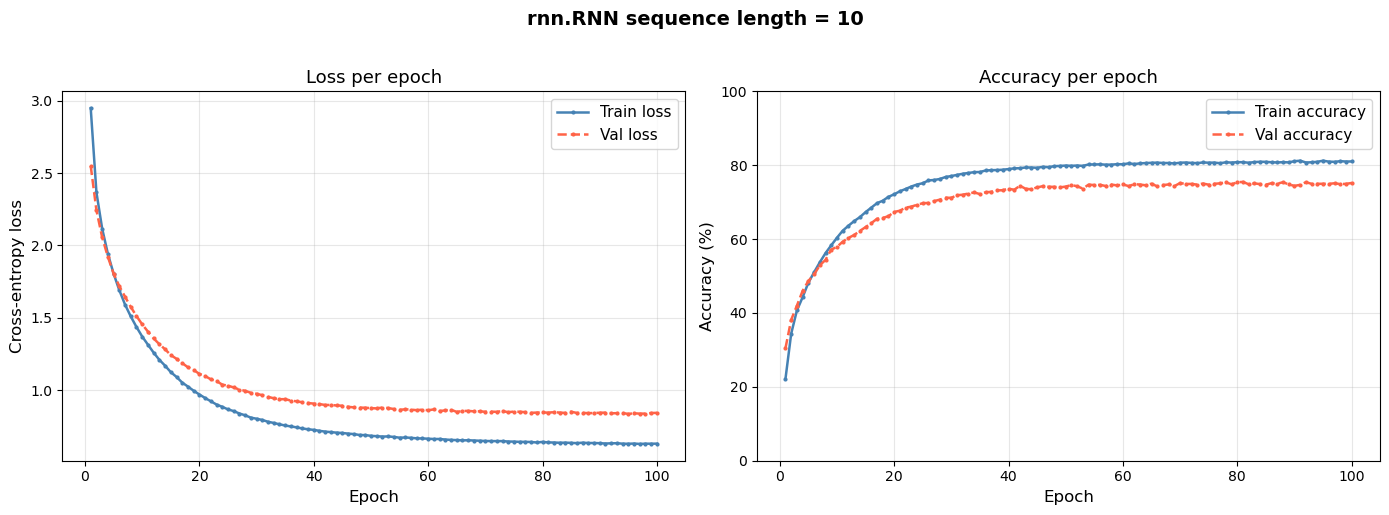

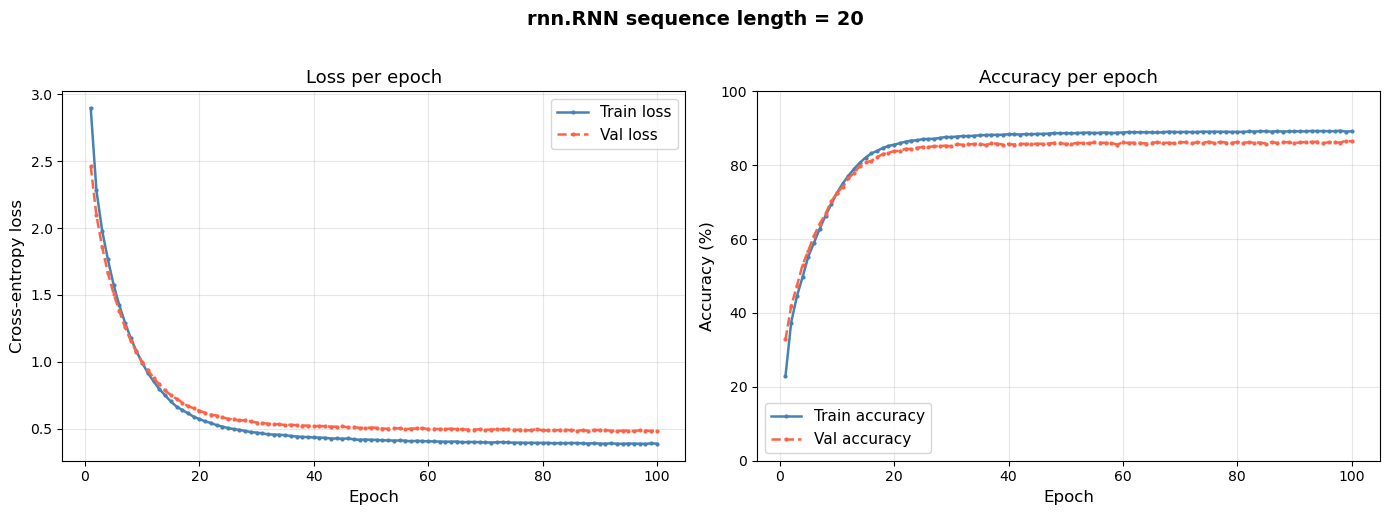

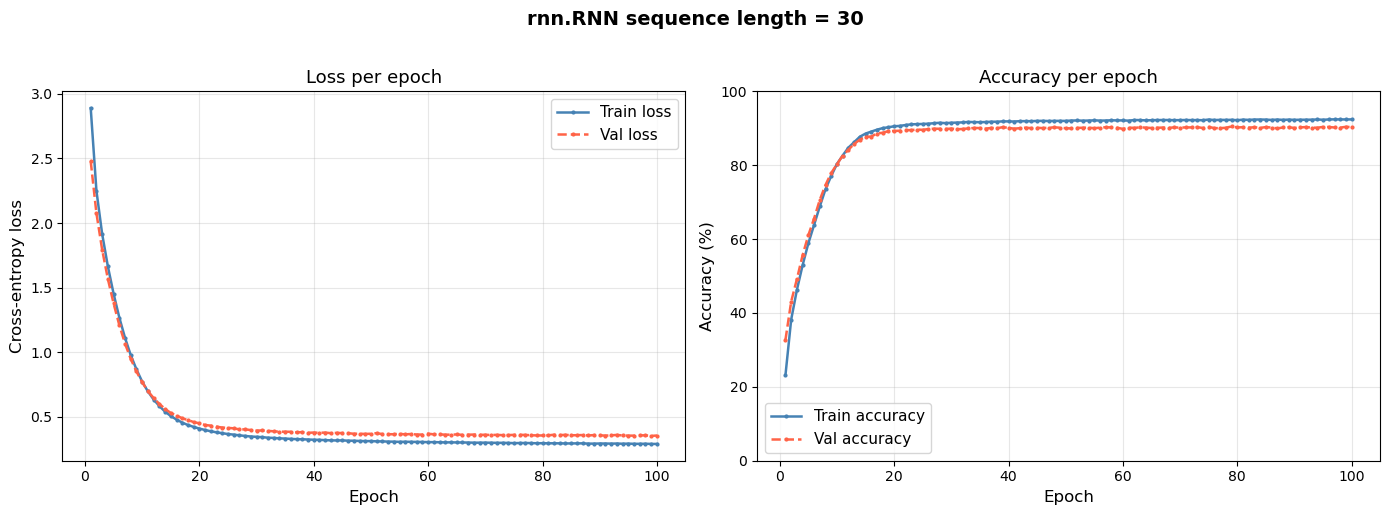

In [83]:
plot_curves(rnn_model, title='rnn.RNN sequence length = 10')
plot_curves(rnn_model20, title='rnn.RNN sequence length = 20')
plot_curves(rnn_model30, title='rnn.RNN sequence length = 30')

In [102]:
class LSTM(CharRNN):
    def __init__(self, eta, n_iter, batch_size, random_state, embed_size, vocab_size, hidden_size):
        super().__init__(eta, n_iter, batch_size, random_state, embed_size, vocab_size, hidden_size)

        self.rnn= nn.LSTM(embed_size,hidden_size,batch_first=True).to(self.device)

    def forward(self,x):
        x=self.embedding(x)
        output,_=self.rnn(x)
        logits=self.fc(output) #get output of the last RNN cell 
        return logits 

In [ ]:
X_train, X_test, y_train, y_test = create_input_output_seq(encoded_text, 10)
lstm_model= LSTM(eta=0.001,n_iter=100,batch_size=32,random_state=42,embed_size=32,vocab_size=45,hidden_size=128)
print(rnn_model)
lstm_model.fit(X_train, y_train, X_test, y_test)


seq_len = 10
  Total samples : 2376
  X_train shape : torch.Size([1900, 10])
  y_train shape : torch.Size([1900, 10])
  X_test shape   : torch.Size([476, 10])
  y_test shape   : torch.Size([476, 10])
Using mps
LSTM(
  (embedding): Embedding(45, 32)
  (rnn): LSTM(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)
Epoch   1/100 | Loss: 3.2310 | Acc: 16.44% | Val Loss: 2.8424 | Val Acc: 23.63% |lr: 0.001000 |Time: 0.3s
Epoch   2/100 | Loss: 2.6403 | Acc: 28.07% | Val Loss: 2.4816 | Val Acc: 32.08% |lr: 0.001000 |Time: 0.2s
Epoch   3/100 | Loss: 2.3513 | Acc: 36.26% | Val Loss: 2.2697 | Val Acc: 38.53% |lr: 0.001000 |Time: 0.2s
Epoch   4/100 | Loss: 2.1546 | Acc: 40.33% | Val Loss: 2.1230 | Val Acc: 41.37% |lr: 0.001000 |Time: 0.2s
Epoch   5/100 | Loss: 2.0062 | Acc: 44.06% | Val Loss: 1.9909 | Val Acc: 44.64% |lr: 0.001000 |Time: 0.3s
Epoch   6/100 | Loss: 1.8763 | Acc: 46.61% | Val Loss: 1.8913 | Val Acc: 47.29% |lr: 0.001000 |Time: 0.2s
Epoch   7/1

LSTM(
  (embedding): Embedding(45, 32)
  (rnn): LSTM(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)

In [104]:
X_train, X_test, y_train, y_test = create_input_output_seq(encoded_text, 20)
lstm_model_20= LSTM(eta=0.001,n_iter=100,batch_size=32,random_state=42,embed_size=32,vocab_size=45,hidden_size=128)
print(lstm_model_20)
lstm_model_20.fit(X_train, y_train, X_test, y_test)


seq_len = 20
  Total samples : 2366
  X_train shape : torch.Size([1892, 20])
  y_train shape : torch.Size([1892, 20])
  X_test shape   : torch.Size([474, 20])
  y_test shape   : torch.Size([474, 20])
Using mps
LSTM(
  (embedding): Embedding(45, 32)
  (rnn): LSTM(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)
Epoch   1/100 | Loss: 3.1890 | Acc: 16.12% | Val Loss: 2.7977 | Val Acc: 24.31% |lr: 0.001000 |Time: 0.5s
Epoch   2/100 | Loss: 2.6214 | Acc: 28.27% | Val Loss: 2.4174 | Val Acc: 33.95% |lr: 0.001000 |Time: 0.2s
Epoch   3/100 | Loss: 2.3020 | Acc: 37.40% | Val Loss: 2.1586 | Val Acc: 41.49% |lr: 0.001000 |Time: 0.3s
Epoch   4/100 | Loss: 2.0702 | Acc: 42.98% | Val Loss: 1.9579 | Val Acc: 46.17% |lr: 0.001000 |Time: 0.3s
Epoch   5/100 | Loss: 1.8809 | Acc: 47.61% | Val Loss: 1.8051 | Val Acc: 50.20% |lr: 0.001000 |Time: 0.3s
Epoch   6/100 | Loss: 1.7265 | Acc: 51.47% | Val Loss: 1.6632 | Val Acc: 53.46% |lr: 0.001000 |Time: 0.3s
Epoch   7/1

LSTM(
  (embedding): Embedding(45, 32)
  (rnn): LSTM(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)

In [105]:
X_train, X_test, y_train, y_test = create_input_output_seq(encoded_text, 30)
lstm_model_30= LSTM(eta=0.001,n_iter=100,batch_size=32,random_state=42,embed_size=32,vocab_size=45,hidden_size=128)
print(lstm_model_30)
lstm_model_30.fit(X_train, y_train, X_test, y_test)


seq_len = 30
  Total samples : 2356
  X_train shape : torch.Size([1884, 30])
  y_train shape : torch.Size([1884, 30])
  X_test shape   : torch.Size([472, 30])
  y_test shape   : torch.Size([472, 30])
Using mps
LSTM(
  (embedding): Embedding(45, 32)
  (rnn): LSTM(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)
Epoch   1/100 | Loss: 3.1614 | Acc: 16.38% | Val Loss: 2.7884 | Val Acc: 25.01% |lr: 0.001000 |Time: 0.4s
Epoch   2/100 | Loss: 2.5627 | Acc: 30.01% | Val Loss: 2.3871 | Val Acc: 35.37% |lr: 0.001000 |Time: 0.2s
Epoch   3/100 | Loss: 2.2290 | Acc: 39.72% | Val Loss: 2.1102 | Val Acc: 42.16% |lr: 0.001000 |Time: 0.3s
Epoch   4/100 | Loss: 1.9770 | Acc: 45.73% | Val Loss: 1.8894 | Val Acc: 47.66% |lr: 0.001000 |Time: 0.4s
Epoch   5/100 | Loss: 1.7754 | Acc: 50.41% | Val Loss: 1.7090 | Val Acc: 52.20% |lr: 0.001000 |Time: 0.3s
Epoch   6/100 | Loss: 1.6071 | Acc: 55.14% | Val Loss: 1.5579 | Val Acc: 56.65% |lr: 0.001000 |Time: 0.2s
Epoch   7/1

LSTM(
  (embedding): Embedding(45, 32)
  (rnn): LSTM(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)

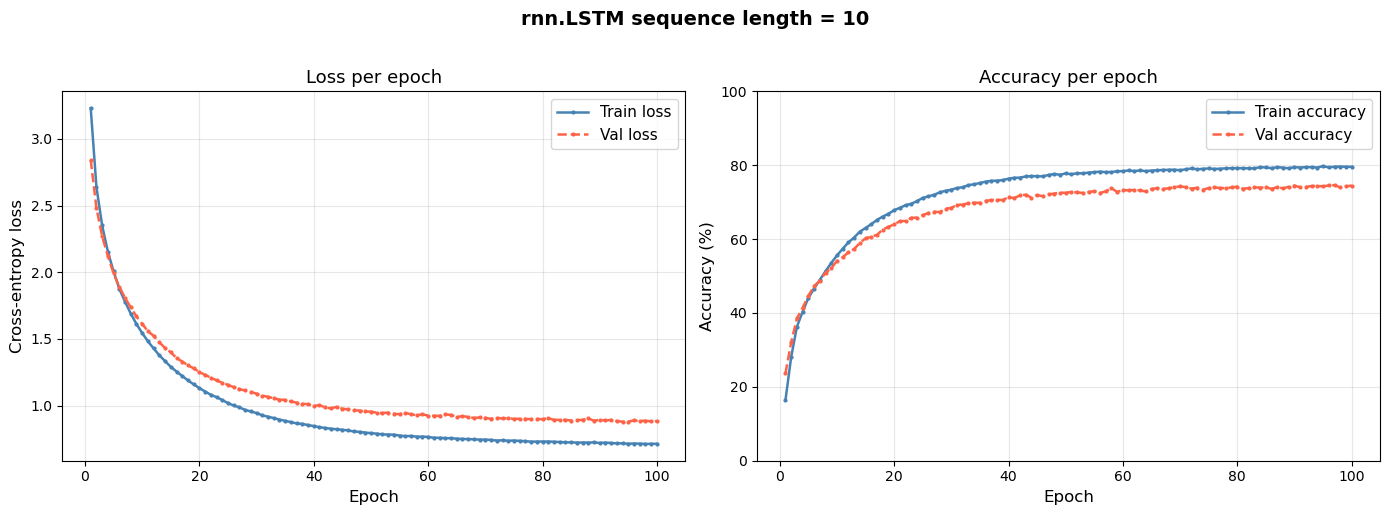

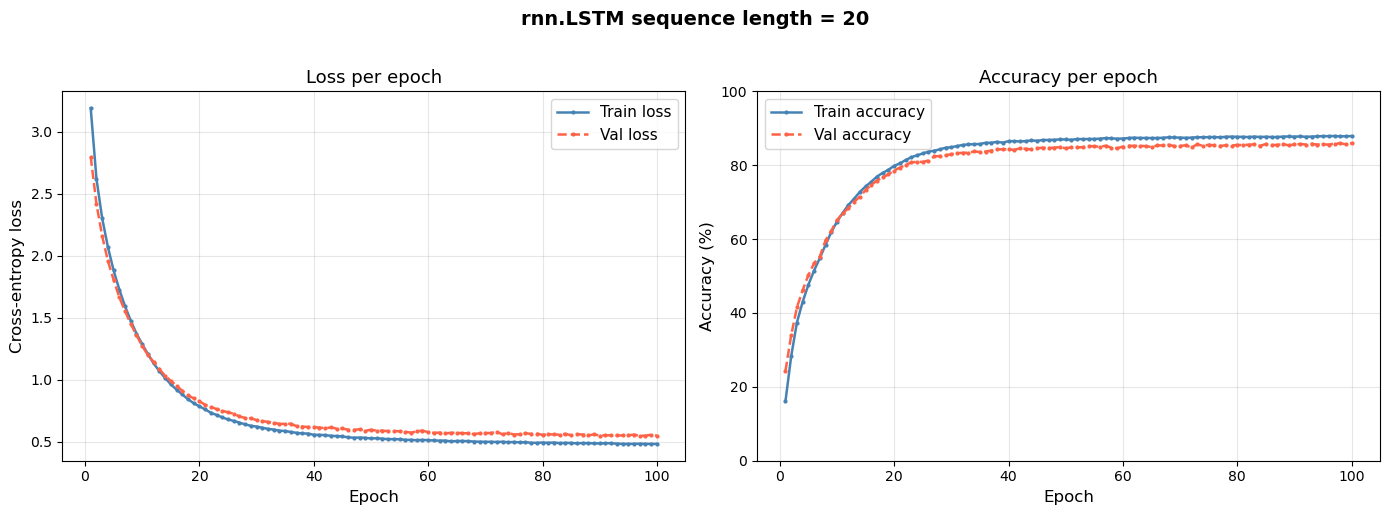

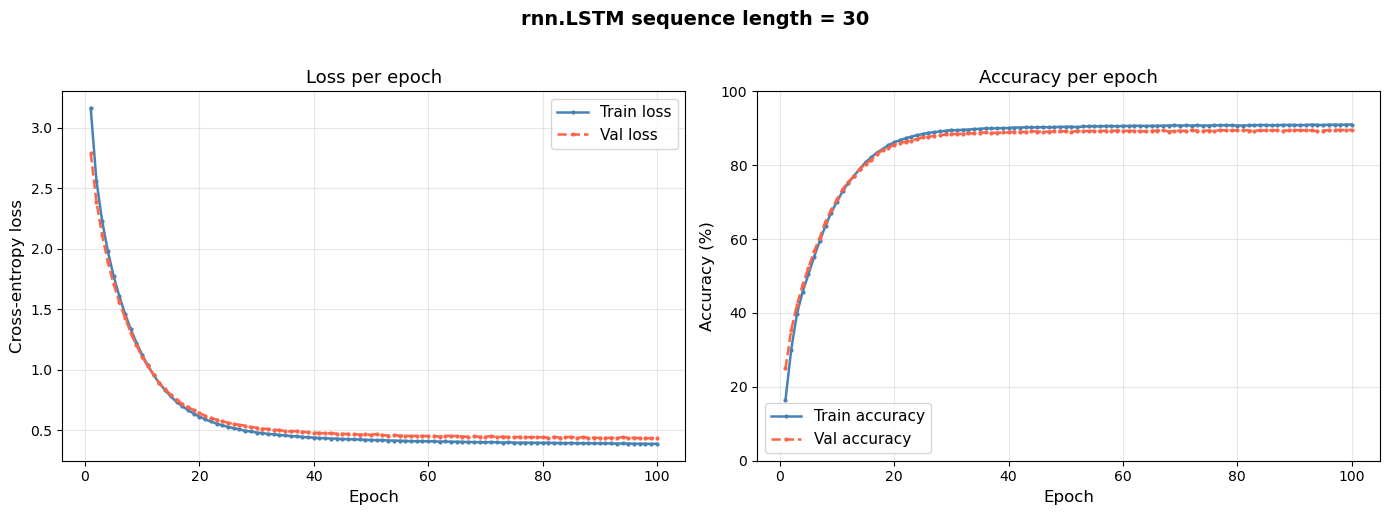

In [106]:
plot_curves(lstm_model, title='rnn.LSTM sequence length = 10')
plot_curves(lstm_model_20, title='rnn.LSTM sequence length = 20')
plot_curves(lstm_model_30, title='rnn.LSTM sequence length = 30')

In [107]:
class GRU(CharRNN):
    def __init__(self, eta, n_iter, batch_size, random_state, embed_size, vocab_size, hidden_size):
        super().__init__(eta, n_iter, batch_size, random_state, embed_size, vocab_size, hidden_size)

        self.rnn= nn.GRU(embed_size,hidden_size,batch_first=True).to(self.device)

In [113]:
X_train, X_test, y_train, y_test = create_input_output_seq(encoded_text, 10)
gru_model= GRU(eta=0.001,n_iter=100,batch_size=32,random_state=42,embed_size=32,vocab_size=45,hidden_size=128)
print(gru_model)
gru_model.fit(X_train, y_train, X_test, y_test)


seq_len = 10
  Total samples : 2376
  X_train shape : torch.Size([1900, 10])
  y_train shape : torch.Size([1900, 10])
  X_test shape   : torch.Size([476, 10])
  y_test shape   : torch.Size([476, 10])
Using mps
GRU(
  (embedding): Embedding(45, 32)
  (rnn): GRU(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)
Epoch   1/100 | Loss: 3.1084 | Acc: 20.15% | Val Loss: 2.6756 | Val Acc: 26.64% |lr: 0.001000 |Time: 0.8s
Epoch   2/100 | Loss: 2.4691 | Acc: 31.54% | Val Loss: 2.3308 | Val Acc: 36.30% |lr: 0.001000 |Time: 0.6s
Epoch   3/100 | Loss: 2.1886 | Acc: 39.29% | Val Loss: 2.1077 | Val Acc: 41.70% |lr: 0.001000 |Time: 0.6s
Epoch   4/100 | Loss: 1.9799 | Acc: 43.76% | Val Loss: 1.9422 | Val Acc: 44.96% |lr: 0.001000 |Time: 0.6s
Epoch   5/100 | Loss: 1.8173 | Acc: 47.35% | Val Loss: 1.8080 | Val Acc: 48.61% |lr: 0.001000 |Time: 0.6s
Epoch   6/100 | Loss: 1.6813 | Acc: 50.80% | Val Loss: 1.7023 | Val Acc: 51.34% |lr: 0.001000 |Time: 0.6s
Epoch   7/100

GRU(
  (embedding): Embedding(45, 32)
  (rnn): GRU(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)

In [114]:
X_train, X_test, y_train, y_test = create_input_output_seq(encoded_text, 20)
gru_model20= GRU(eta=0.001,n_iter=100,batch_size=32,random_state=42,embed_size=32,vocab_size=45,hidden_size=128)
print(gru_model20)
gru_model20.fit(X_train, y_train, X_test, y_test)


seq_len = 20
  Total samples : 2366
  X_train shape : torch.Size([1892, 20])
  y_train shape : torch.Size([1892, 20])
  X_test shape   : torch.Size([474, 20])
  y_test shape   : torch.Size([474, 20])
Using mps
GRU(
  (embedding): Embedding(45, 32)
  (rnn): GRU(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)
Epoch   1/100 | Loss: 3.0507 | Acc: 19.98% | Val Loss: 2.5950 | Val Acc: 28.24% |lr: 0.001000 |Time: 1.1s
Epoch   2/100 | Loss: 2.4095 | Acc: 32.98% | Val Loss: 2.2095 | Val Acc: 39.69% |lr: 0.001000 |Time: 1.0s
Epoch   3/100 | Loss: 2.0860 | Acc: 41.91% | Val Loss: 1.9322 | Val Acc: 45.97% |lr: 0.001000 |Time: 1.0s
Epoch   4/100 | Loss: 1.8288 | Acc: 47.77% | Val Loss: 1.7204 | Val Acc: 50.76% |lr: 0.001000 |Time: 1.0s
Epoch   5/100 | Loss: 1.6249 | Acc: 53.37% | Val Loss: 1.5384 | Val Acc: 55.80% |lr: 0.001000 |Time: 1.0s
Epoch   6/100 | Loss: 1.4481 | Acc: 58.48% | Val Loss: 1.3770 | Val Acc: 60.81% |lr: 0.001000 |Time: 1.1s
Epoch   7/100

GRU(
  (embedding): Embedding(45, 32)
  (rnn): GRU(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)

In [115]:
X_train, X_test, y_train, y_test = create_input_output_seq(encoded_text, 30)
gru_model30= GRU(eta=0.001,n_iter=100,batch_size=32,random_state=42,embed_size=32,vocab_size=45,hidden_size=128)
print(gru_model30)
gru_model30.fit(X_train, y_train, X_test, y_test)


seq_len = 30
  Total samples : 2356
  X_train shape : torch.Size([1884, 30])
  y_train shape : torch.Size([1884, 30])
  X_test shape   : torch.Size([472, 30])
  y_test shape   : torch.Size([472, 30])
Using mps
GRU(
  (embedding): Embedding(45, 32)
  (rnn): GRU(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)
Epoch   1/100 | Loss: 3.0330 | Acc: 20.22% | Val Loss: 2.6012 | Val Acc: 27.70% |lr: 0.001000 |Time: 1.4s
Epoch   2/100 | Loss: 2.3700 | Acc: 34.42% | Val Loss: 2.1901 | Val Acc: 40.42% |lr: 0.001000 |Time: 1.4s
Epoch   3/100 | Loss: 2.0128 | Acc: 43.85% | Val Loss: 1.8799 | Val Acc: 47.02% |lr: 0.001000 |Time: 1.4s
Epoch   4/100 | Loss: 1.7306 | Acc: 50.73% | Val Loss: 1.6301 | Val Acc: 53.96% |lr: 0.001000 |Time: 1.4s
Epoch   5/100 | Loss: 1.4974 | Acc: 57.25% | Val Loss: 1.4125 | Val Acc: 60.20% |lr: 0.001000 |Time: 1.4s
Epoch   6/100 | Loss: 1.2911 | Acc: 62.91% | Val Loss: 1.2237 | Val Acc: 65.58% |lr: 0.001000 |Time: 1.4s
Epoch   7/100

GRU(
  (embedding): Embedding(45, 32)
  (rnn): GRU(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)

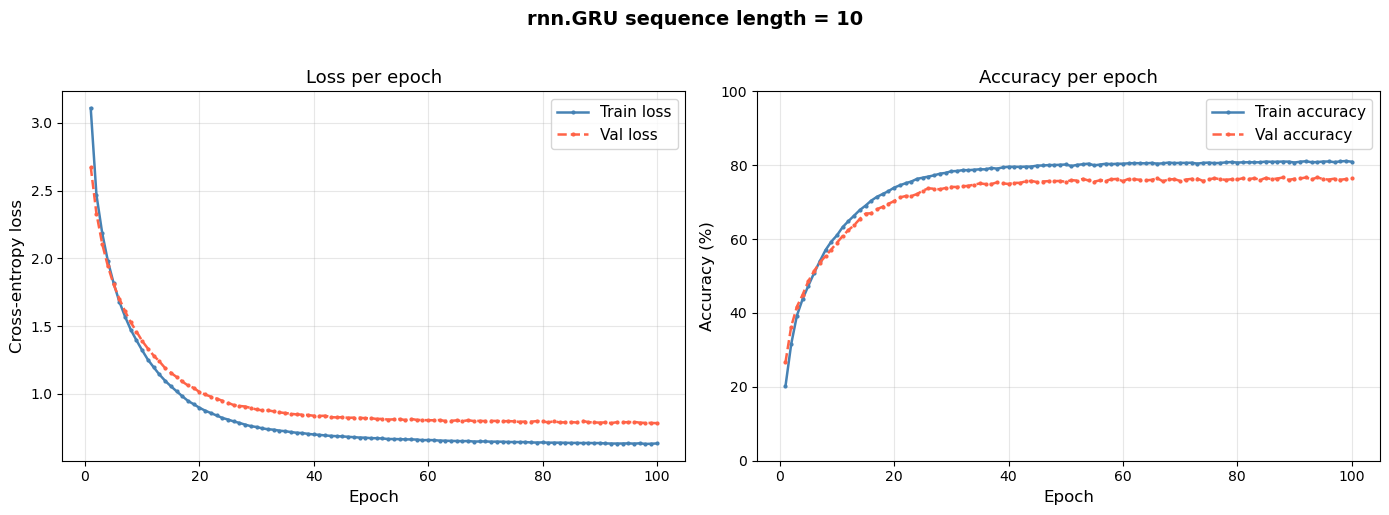

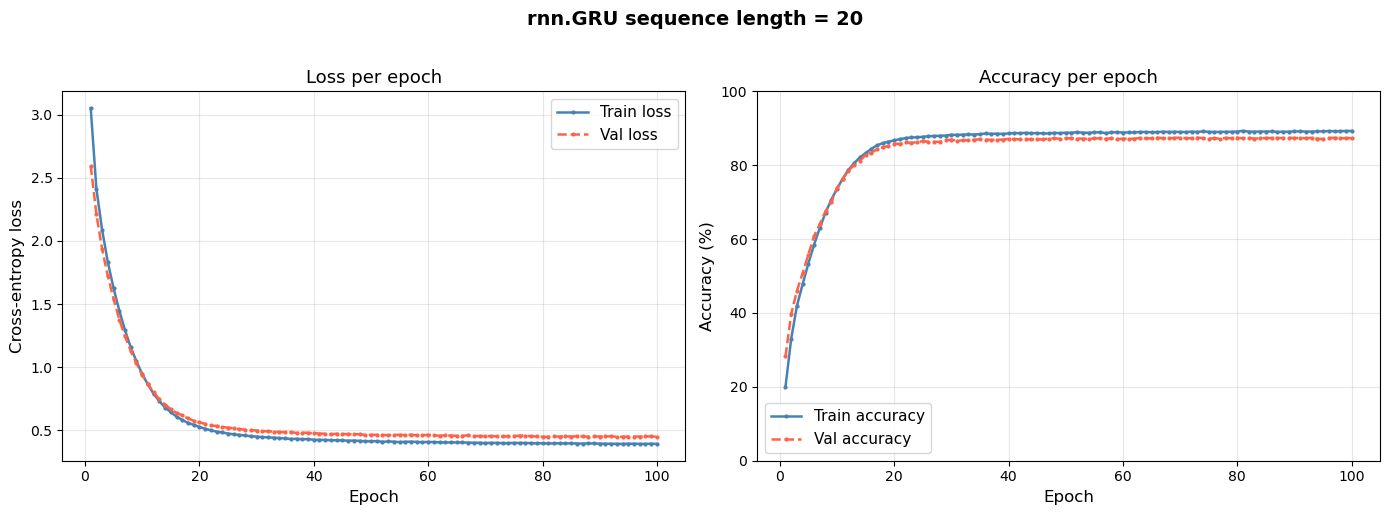

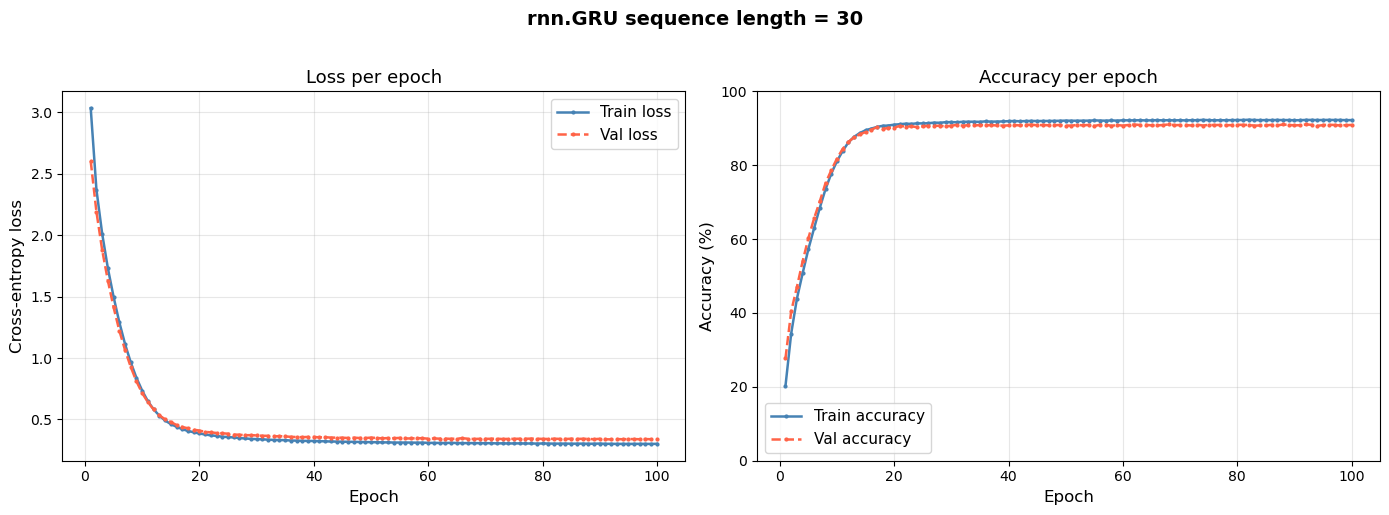

In [116]:
plot_curves(gru_model, title='rnn.GRU sequence length = 10')
plot_curves(gru_model20, title='rnn.GRU sequence length = 20')
plot_curves(gru_model30, title='rnn.GRU sequence length = 30')

In [ ]:



# Step 2: Prepare the dataset
sequence_length = 20
# Create a character mapping to integers
chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode the text into integers
encoded_text = [char_to_int[ch] for ch in text]

# Create sequences and targets
sequences = []
targets = []
for i in range(0, len(encoded_text) - sequence_length):
    seq = encoded_text[i:i+sequence_length]
    target = encoded_text[i+sequence_length]
    sequences.append(seq)
    targets.append(target)

# Convert lists to PyTorch tensors
sequences = torch.tensor(sequences, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)

# Step 3: Create a dataset class
class CharDataset():
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]

# Instantiate the dataset
dataset = CharDataset(sequences, targets)

# Step 4: Create data loaders
batch_size = 128
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

#print(f"\nseq_len = {seq_len}")
#print(f"  Total samples : {len(X)}")
print(f"  X_train shape : {X_train.shape}")   # (N_train, seq_len)
print(f"  y_train shape : {y_train.shape}")   # (N_train, seq_len)
print(f"  X_test shape   : {X_test.shape}")
print(f"  y_test shape   : {y_test.shape}")
# Now `train_loader` and `test_loader` are ready to be used in a training loop

  X_train shape : torch.Size([1884, 30])
  y_train shape : torch.Size([1884, 30])
  X_test shape   : torch.Size([472, 30])
  y_test shape   : torch.Size([472, 30])


In [ ]:
X_train, X_test, y_train, y_test = create_input_output_seq(shakespeare_encoded_text, 20)
lstm_model_2a= LSTM(eta=0.001,n_iter=50,batch_size=128,random_state=42,embed_size=32,vocab_size=65,hidden_size=128)
print(lstm_model_2a)
lstm_model_2a.fit(X_train, y_train, X_test, y_test)


seq_len = 20
  Total samples : 1115374
  X_train shape : torch.Size([892299, 20])
  y_train shape : torch.Size([892299, 20])
  X_test shape   : torch.Size([223075, 20])
  y_test shape   : torch.Size([223075, 20])
Using mps
LSTM(
  (embedding): Embedding(65, 32)
  (rnn): LSTM(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=65, bias=True)
)
Epoch   1/50 | Loss: 2.0375 | Acc: 41.42% | Val Loss: 1.9847 | Val Acc: 42.88% |lr: 0.001000 |Time: 85.0s
Epoch   2/50 | Loss: 1.9718 | Acc: 43.17% | Val Loss: 1.9717 | Val Acc: 43.13% |lr: 0.001000 |Time: 89.4s
Epoch   3/50 | Loss: 1.9623 | Acc: 43.36% | Val Loss: 1.9579 | Val Acc: 43.42% |lr: 0.001000 |Time: 93.5s
Epoch   4/50 | Loss: 1.9581 | Acc: 43.44% | Val Loss: 1.9570 | Val Acc: 43.56% |lr: 0.001000 |Time: 114.3s
Epoch   5/50 | Loss: 1.9556 | Acc: 43.48% | Val Loss: 1.9553 | Val Acc: 43.46% |lr: 0.001000 |Time: 113.0s
Epoch   6/50 | Loss: 1.9528 | Acc: 43.54% | Val Loss: 1.9545 | Val Acc: 43.50% |lr: 0.001000 |Time: 10

LSTM(
  (embedding): Embedding(65, 32)
  (rnn): LSTM(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=65, bias=True)
)

In [146]:
X_train, X_test, y_train, y_test = create_input_output_seq(shakespeare_encoded_text, 30)
lstm_model_2b= LSTM(eta=0.001,n_iter=50,batch_size=128,random_state=42,embed_size=32,vocab_size=65,hidden_size=128)
print(lstm_model_2b)
lstm_model_2b.fit(X_train, y_train, X_test, y_test)


seq_len = 30
  Total samples : 1115364
  X_train shape : torch.Size([892291, 30])
  y_train shape : torch.Size([892291, 30])
  X_test shape   : torch.Size([223073, 30])
  y_test shape   : torch.Size([223073, 30])
Using mps
LSTM(
  (embedding): Embedding(65, 32)
  (rnn): LSTM(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=65, bias=True)
)
Epoch   1/50 | Loss: 2.0585 | Acc: 40.97% | Val Loss: 1.9706 | Val Acc: 42.88% |lr: 0.001000 |Time: 25.7s
Epoch   2/50 | Loss: 1.9504 | Acc: 43.64% | Val Loss: 1.9451 | Val Acc: 43.89% |lr: 0.001000 |Time: 23.6s
Epoch   3/50 | Loss: 1.9341 | Acc: 44.14% | Val Loss: 1.9376 | Val Acc: 43.92% |lr: 0.001000 |Time: 23.5s
Epoch   4/50 | Loss: 1.9269 | Acc: 44.36% | Val Loss: 1.9323 | Val Acc: 44.22% |lr: 0.001000 |Time: 23.1s
Epoch   5/50 | Loss: 1.9220 | Acc: 44.51% | Val Loss: 1.9356 | Val Acc: 44.17% |lr: 0.001000 |Time: 23.1s
Epoch   6/50 | Loss: 1.9185 | Acc: 44.60% | Val Loss: 1.9256 | Val Acc: 44.36% |lr: 0.001000 |Time: 23.1

LSTM(
  (embedding): Embedding(65, 32)
  (rnn): LSTM(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=65, bias=True)
)

In [152]:

def count_parameters(model):
    total  = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total, trainable = count_parameters(lstm_model)
print(f"Total parameters    : {total:,}")
print(f"Trainable parameters: {trainable:,}")

def model_size_mb(model):
    total_params = sum(p.numel() for p in model.parameters())
    # each parameter is a float32 = 4 bytes
    size_bytes = total_params * 4
    return size_bytes / (1024 ** 2)

print(f"Model size: {model_size_mb(lstm_model):.3f} MB")

def measure_inference_time(model, X_sample, n_runs=100):
    model.eval()
    X_sample = X_sample.to(model.device)
    
    with torch.no_grad():
        # warmup
        _ = model(X_sample)
        
        start = time.time()
        for _ in range(n_runs):
            _ = model(X_sample)
        end = time.time()
    
    avg_ms = (end - start) / n_runs * 1000
    return avg_ms

# use a small fixed batch for fair comparison across models
sample = X_test[:32]
lstm_inference_ms = measure_inference_time(lstm_model, sample)
gru_inference_ms  = measure_inference_time(gru_model,  sample)
print(f"LSTM inference: {lstm_inference_ms:.2f}ms per batch")
print(f"GRU  inference: {gru_inference_ms:.2f}ms per batch")

def model_summary(name, model, val_loss, val_acc, training_time, inference_ms):
    total_params, _ = count_parameters(model)
    size_mb         = model_size_mb(model)
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Parameters     : {total_params:,}")
    print(f"  Model size     : {size_mb:.3f} MB")
    print(f"  Val Loss       : {val_loss:.4f}")
    print(f"  Val Accuracy   : {val_acc:.2f}%")
    print(f"  Training time  : {training_time:.1f}s")
    print(f"  Inference time : {inference_ms:.2f}ms / batch")

# call after training each model
model_summary("LSTM seq_len=30", lstm_model_2b, 
              lstm_model_2b.val_losses_[-1], 
              lstm_model_2b.val_accuracies_[-1],
              lstm_model_2b.training_time_,
              lstm_inference_ms)

# model_summary("GRU  seq_len=20", gru_model,
#               gru_model.val_losses_[-1],
#               gru_model.val_accuracies_[-1],
#               gru_model.training_time_,
#               gru_inference_ms)

Total parameters    : 90,189
Trainable parameters: 90,189
Model size: 0.344 MB
LSTM inference: 0.41ms per batch
GRU  inference: 6.64ms per batch

  LSTM seq_len=30
  Parameters     : 93,409
  Model size     : 0.356 MB
  Val Loss       : 1.9137
  Val Accuracy   : 44.55%
  Training time  : 1639.3s
  Inference time : 0.41ms / batch


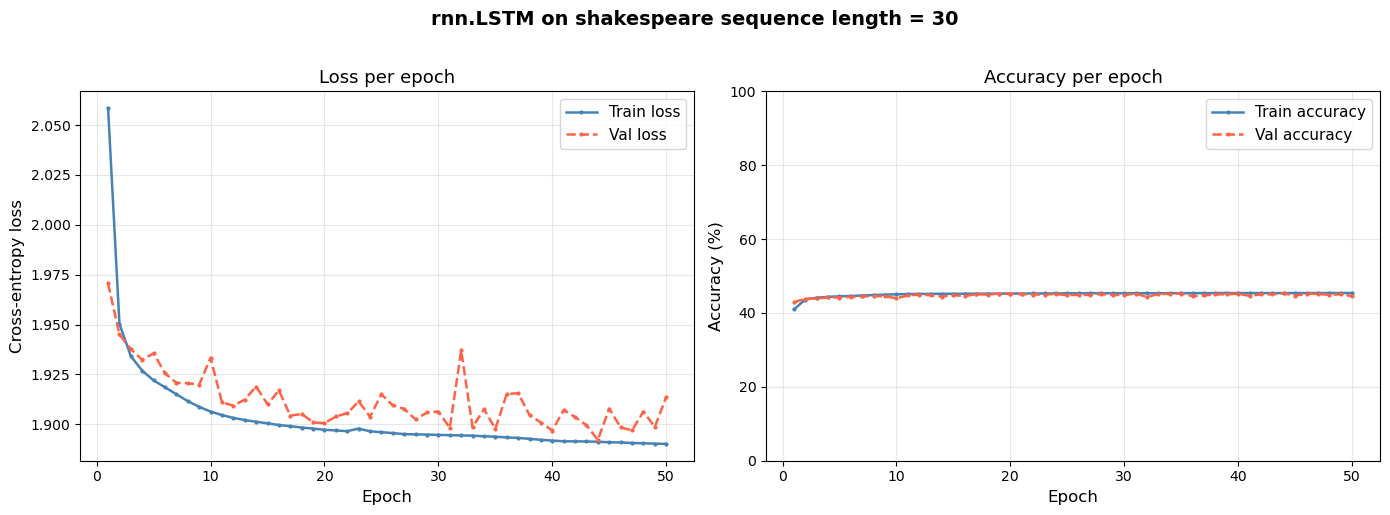

In [154]:
plot_curves(lstm_model_2b, title='rnn.LSTM on shakespeare sequence length = 30')